<a href="https://colab.research.google.com/github/bipul-ranjan/Kaggle/blob/Telecom_churn/Telecom_Churn_Kaggle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Problem statement
In the telecom industry, customers are able to choose from multiple service providers and actively switch from one operator to another. In this highly competitive market, the telecommunications industry experiences an average of 15-25% annual churn rate. Given the fact that it costs 5-10 times more to acquire a new customer than to retain an existing one, customer retention has now become even more important than customer acquisition.

For many incumbent operators, retaining high profitable customers is the number one business goal. To reduce customer churn, telecom companies need to predict which customers are at high risk of churn. In this project, you will analyze customer-level data of a leading telecom firm, build predictive models to identify customers at high risk of churn, and identify the main indicators of churn.



### Customer behaviour during churn:

Customers usually do not decide to switch to another competitor instantly, but rather over a period of time (this is especially applicable to high-value customers). In churn prediction, we assume
that there are three phases of customer lifecycle :

* `The ‘good’ phase:` In this phase, the customer is happy with the
service and behaves as usual.

* `The ‘action’ phase: `The customer experience starts to sore in this phase, for e.g. he/she gets a compelling offer from a competitor, faces unjust charges, becomes unhappy with service quality etc. In this phase, the customer usually shows different behaviour than the ‘good’ months. It is crucial to identify high-churn-risk customers in this phase, since some corrective actions can be taken at this point (such as matching the competitor’s offer/improving the service quality etc.)

* `The ‘churn’ phase:` In this phase, the customer is said to have churned. In this case, since you are working over a four-month window, the first two months are the ‘good’ phase, the third month is the ‘action’ phase, while the fourth month (September) is the ‘churn’ phase.

## 1. Data understanding, preparation & pre-processing (10 %)

1.   Has used imputation techniques to treat missing values
2.  Has identified potentially useful and non-useful attributes using feature importance and impact estimation.

## 2. EDA and Feature Engineering (30 %)


1.   Has Performed correlation analysis between variables and has used plots to identify relationships between variables
2.   Has Performed advanced data analysis, including plotting heatmaps and histograms
3.   Has Performed feature engineering i.e. one or more methods on attributes that lead to the creation of a new potentially useful variable e.g. day from the date
3.   Has applied variable transformation which are methods to turn categorical variable into numerical data and scale transformations to numerical data

## 3. Model selection, model building, evaluation & prediction (35 %)


1.   Has tried more than one model for training and evaluation purposes on respective metric
2.   Has used cross-validation and hyperparameter tuning for each model
3.   Choosing the best model based on the fit of the dataset and output variable. The relevant evaluation metrics have been calculated and interpreted correctly as per the business context

## 4. Code readability and conciseness (5%)


1.   The code is well commented and the text is written in detail to explain the thought process.
2.   Efficient, concise code is written.










## 1. Importing important libraries

In [124]:
# Import Data Structure
import numpy as np
import pandas as pd

# import datetime
import datetime

# Import Visualization modules
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

# Import the machine learning module
from sklearn.model_selection import train_test_split
# Logistic regression
from sklearn.linear_model import LogisticRegression
# Support vector machine
from sklearn.svm import SVC
# Using decision tree
from sklearn.tree import DecisionTreeClassifier
# Importing gridsearch
from sklearn.model_selection import GridSearchCV
# Import Random forrest
from sklearn.ensemble import RandomForestClassifier

# import export_graphviz
from sklearn.tree import export_graphviz
# import pydotplus
from six import StringIO
from IPython.display import Image
import pydotplus


from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
from sklearn.decomposition import PCA


# Import Warnings
import warnings
warnings.filterwarnings('ignore')

## 2. Uploading the data

In [125]:
df_telecom_train = pd.read_csv('/content/drive/MyDrive/Data-For-Analysis/Kaggle/Telecom_Churn/train.csv', encoding='ISO-8859-1')
df_telecom_test = pd.read_csv('/content/drive/MyDrive/Data-For-Analysis/Kaggle/Telecom_Churn/test.csv',encoding='ISO-8859-1')
df_telecom_submission = pd.read_csv('/content/drive/MyDrive/Data-For-Analysis/Kaggle/Telecom_Churn/sample.csv',encoding='ISO-8859-1')
df_telecom_dictionary = pd.read_csv('/content/drive/MyDrive/Data-For-Analysis/Kaggle/Telecom_Churn/data_dictionary.csv',encoding='ISO-8859-1')

In [126]:
# Print the shape of dataframe
print("Shape of train data: ",df_telecom_train.shape)
print("Shape of test data: ",df_telecom_test.shape)
print("Shape of dictionary: ",df_telecom_dictionary.shape)

Shape of train data:  (69999, 172)
Shape of test data:  (30000, 171)
Shape of dictionary:  (36, 2)


### 2.1 Understanding of data dictionary

**data_dictionary.csv:** This contains the definitions for the various acronyms.

For example, the variable **total_og_mou_7,** contains the acronyms **total, og, mou, and 7**, which can be translated as the **total outgoing minutes of voice calls made by the user in month of July.**

In [127]:
# Wrap Description column while printing and left aligned values
pd.set_option('display.max_colwidth', None)
pd.set_option('display.colheader_justify', 'left')
df_telecom_dictionary

,Acronyms,Description
0,CIRCLE_ID,Telecom circle area to which the customer belongs to
1,LOC,Local calls within same telecom circle
2,STD,STD calls outside the calling circle
3,IC,Incoming calls
4,OG,Outgoing calls
5,T2T,Operator T to T ie within same operator mobile to mobile
6,T2M,Operator T to other operator mobile
7,T2O,Operator T to other operator fixed line
8,T2F,Operator T to fixed lines of T
9,T2C,Operator T to its own call center


In [128]:
# Print columns of train data
df_telecom_train.columns

Index(['id', 'circle_id', 'loc_og_t2o_mou', 'std_og_t2o_mou', 'loc_ic_t2o_mou',
       'last_date_of_month_6', 'last_date_of_month_7', 'last_date_of_month_8',
       'arpu_6', 'arpu_7',
       ...
       'sachet_3g_7', 'sachet_3g_8', 'fb_user_6', 'fb_user_7', 'fb_user_8',
       'aon', 'aug_vbc_3g', 'jul_vbc_3g', 'jun_vbc_3g', 'churn_probability'],
      dtype='object', length=172)

## 3. Data understanding, preparation & pre-processing: Handeling on missing data

In [129]:
# Print the info of train data set
print("**************************Info of train data: *****************************************************","\n\n")
print(df_telecom_train.info(verbose=1,show_counts=1))

**************************Info of train data: ***************************************************** 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69999 entries, 0 to 69998
Data columns (total 172 columns):
 #    Column                    Non-Null Count  Dtype  
---   ------                    --------------  -----  
 0    id                        69999 non-null  int64  
 1    circle_id                 69999 non-null  int64  
 2    loc_og_t2o_mou            69297 non-null  float64
 3    std_og_t2o_mou            69297 non-null  float64
 4    loc_ic_t2o_mou            69297 non-null  float64
 5    last_date_of_month_6      69999 non-null  object 
 6    last_date_of_month_7      69600 non-null  object 
 7    last_date_of_month_8      69266 non-null  object 
 8    arpu_6                    69999 non-null  float64
 9    arpu_7                    69999 non-null  float64
 10   arpu_8                    69999 non-null  float64
 11   onnet_mou_6               67231 non-null  float64
 12

In [130]:
# Get Dependent and Independent Variable
X = df_telecom_train.drop('churn_probability',axis=1)
y = df_telecom_train['churn_probability']

In [131]:
# Print all columns has missing values
col_missing_val = X.isnull().sum()
col_missing_val = col_missing_val[col_missing_val>0].reset_index()
col_missing_val.columns = ['Column_Name','Missing_Values']
col_missing_val = col_missing_val.sort_values(by='Missing_Values',ascending=False)
col_missing_val['%Missing']= round((col_missing_val['Missing_Values']/X.shape[0]*100),2)
col_missing_val


,Column_Name,Missing_Values,%Missing
101,max_rech_data_6,52431,74.90
122,fb_user_6,52431,74.90
95,date_of_last_rech_data_6,52431,74.90
110,av_rech_amt_data_6,52431,74.90
119,night_pck_user_6,52431,74.90
...,...,...,...
4,last_date_of_month_8,733,1.05
1,std_og_t2o_mou,702,1.00
2,loc_ic_t2o_mou,702,1.00
0,loc_og_t2o_mou,702,1.00


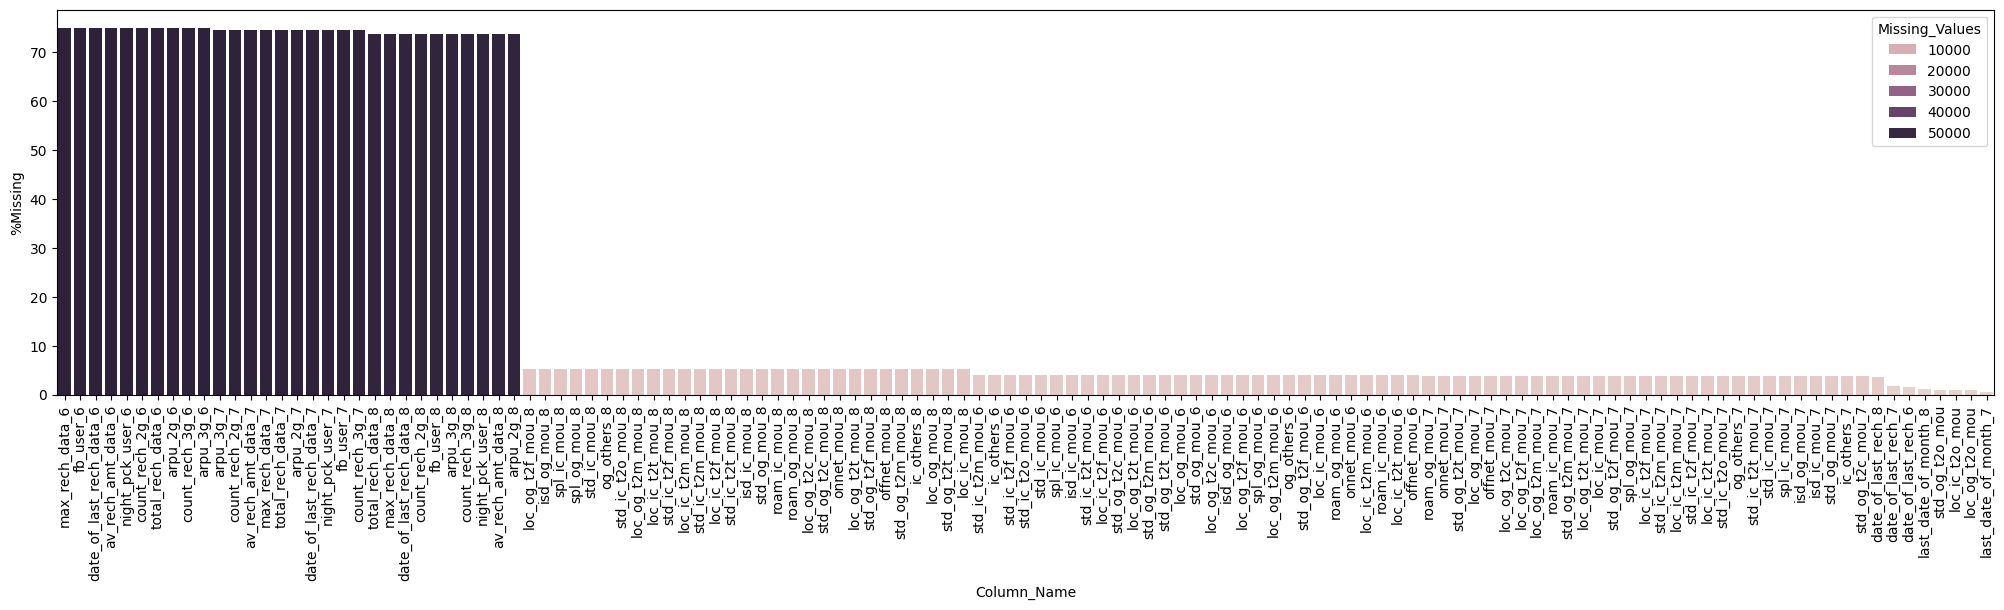

In [132]:
# Put SNS barchart with % missing values
plt.figure(figsize=(25,5))
sns.barplot(x=col_missing_val['Column_Name'],y=col_missing_val['%Missing'],hue=col_missing_val['Missing_Values'])
plt.xticks(rotation=90)
plt.show()

## Data understanding, preparation & pre-processing :Dropping the columns having greater than 70% of missing values

In [133]:
col_miss_val_grt_70 = col_missing_val[col_missing_val['%Missing']>70]['Column_Name']
X_rem_grt_70_miss = X.drop(col_miss_val_grt_70,axis=1)
X_rem_grt_70_miss.shape

col_miss_val_2 = X_rem_grt_70_miss.isnull().sum()
col_miss_val_2 = col_miss_val_2[col_miss_val_2>0].reset_index()
col_miss_val_2.columns = ['Column_Name','Missing_Values']
col_miss_val_2['%Missing']= round((col_miss_val_2['Missing_Values']/X_rem_grt_70_miss.shape[0]*100),2)
col_miss_val_2 = col_miss_val_2.sort_values(by='Missing_Values',ascending=False)
col_miss_val_2

,Column_Name,Missing_Values,%Missing
43,std_og_t2c_mou_8,3703,5.29
31,loc_og_mou_8,3703,5.29
22,loc_og_t2m_mou_8,3703,5.29
64,loc_ic_t2f_mou_8,3703,5.29
25,loc_og_t2f_mou_8,3703,5.29
...,...,...,...
4,last_date_of_month_8,733,1.05
1,std_og_t2o_mou,702,1.00
2,loc_ic_t2o_mou,702,1.00
0,loc_og_t2o_mou,702,1.00


<Figure size 2500x500 with 0 Axes>

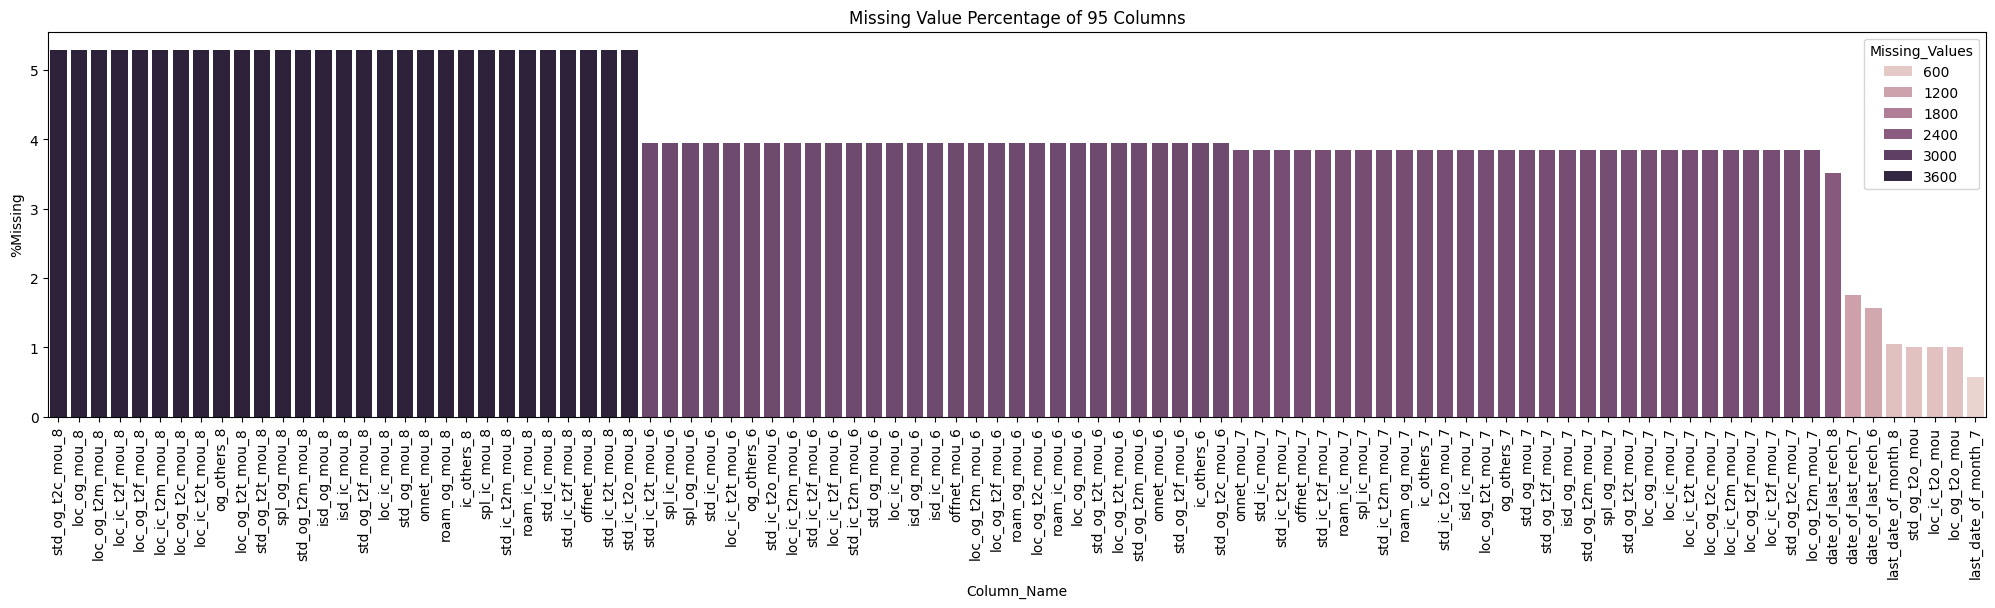

In [134]:
# plot the missing value %
plt.figure(figsize=(25,5))
# plot the missing value %
plt.figure(figsize=(25,5))
sns.barplot(x=col_miss_val_2['Column_Name'],y=col_miss_val_2['%Missing'],hue=col_miss_val_2['Missing_Values'])
plt.xticks(rotation=90)
plt.title('Missing Value Percentage of ' + str(col_miss_val_2.shape[0]) + ' Columns')
plt.show()

In [135]:
# Count of column in missing value with suffix in column name as mou or minutes of voice calls
print(col_miss_val_2[col_miss_val_2['Column_Name'].str.contains('mou')].shape[0],'  columns in missing value with suffix in column name as mou or minutes of voice calls')


84   columns in missing value with suffix in column name as mou or minutes of voice calls


Since mou i.e. minutes of voice calls is missing data hence we will be replacing this with 0

In [136]:
# Replacing missing value of all columns containing mou to 0
mou_cols = col_miss_val_2[col_miss_val_2['Column_Name'].str.contains('mou')]['Column_Name']

for col in mou_cols:
  X_rem_grt_70_miss[col].fillna(0,inplace=True)

col_miss_val_3 = X_rem_grt_70_miss.isnull().sum()
col_miss_val_3 = col_miss_val_3[col_miss_val_3>0].reset_index()
col_miss_val_3.columns = ['Column_Name','Missing_Values']
col_miss_val_3

,Column_Name,Missing_Values
0,last_date_of_month_7,399
1,last_date_of_month_8,733
2,og_others_6,2768
3,og_others_7,2687
4,og_others_8,3703
5,ic_others_6,2768
6,ic_others_7,2687
7,ic_others_8,3703
8,date_of_last_rech_6,1101
9,date_of_last_rech_7,1234


## Data understanding, preparation & pre-processing : Making the value 0 for outgoing and incoming calls

In [137]:
col_og_ic = col_miss_val_2[col_miss_val_2['Column_Name'].str.contains('og|ic')]['Column_Name']
for col in col_og_ic:
  X_rem_grt_70_miss[col].fillna(0,inplace=True)

col_miss_val_4 = X_rem_grt_70_miss.isnull().sum()
col_miss_val_4 = col_miss_val_4[col_miss_val_4>0].reset_index()
col_miss_val_4.columns = ['Column_Name','Missing_Values']
col_miss_val_4

,Column_Name,Missing_Values
0,last_date_of_month_7,399
1,last_date_of_month_8,733
2,date_of_last_rech_6,1101
3,date_of_last_rech_7,1234
4,date_of_last_rech_8,2461


## Data understanding, preparation & pre-processing : Drop all last date of month column as it will have no impact on the prediction

In [138]:
X_rem_grt_70_miss.shape

(69999, 141)

In [139]:
col_1 =[]
for col in X_rem_grt_70_miss.columns:
  if 'last_date_of_month' in col:
    col_1.append(col)
  elif 'date_of_last_rech' in col:
    col_1.append(col)

print("last date of columns: ",col_1)

last date of columns:  ['last_date_of_month_6', 'last_date_of_month_7', 'last_date_of_month_8', 'date_of_last_rech_6', 'date_of_last_rech_7', 'date_of_last_rech_8']


In [140]:
# Dropping all date columns in col_1 variable as it will have no impact on churn prediction
X_clean_data = X_rem_grt_70_miss.drop(col_1,axis=1)
X_clean_data.shape

(69999, 135)

In [141]:
X.columns

Index(['id', 'circle_id', 'loc_og_t2o_mou', 'std_og_t2o_mou', 'loc_ic_t2o_mou',
       'last_date_of_month_6', 'last_date_of_month_7', 'last_date_of_month_8',
       'arpu_6', 'arpu_7',
       ...
       'sachet_3g_6', 'sachet_3g_7', 'sachet_3g_8', 'fb_user_6', 'fb_user_7',
       'fb_user_8', 'aon', 'aug_vbc_3g', 'jul_vbc_3g', 'jun_vbc_3g'],
      dtype='object', length=171)

In [142]:
# Print unique value of circle ID
print("Unique value of circle ID: ",X_clean_data['circle_id'].unique())

Unique value of circle ID:  [109]


In [143]:
# Dropping ID column and circle id as circle has only one value 109
X_clean_data.drop(['id','circle_id'],axis=1,inplace=True)

## EDA and Feature Engineering: Exploratory data avalysis for the clean data

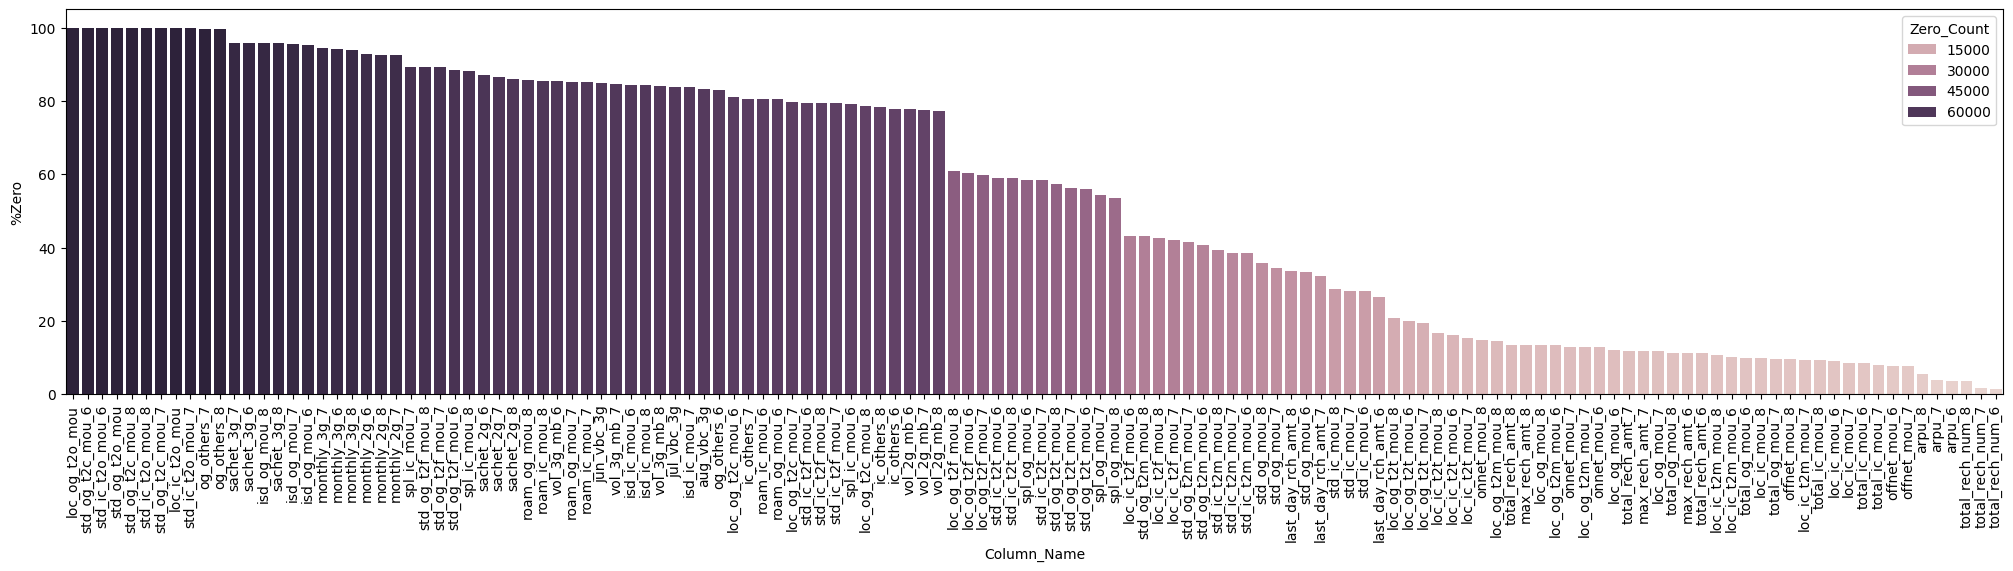

In [144]:
# Count number and % of zero in every column
col_zero_count = (X_clean_data==0).sum()
col_zero_count = col_zero_count[col_zero_count>0].reset_index().sort_values(by=0,ascending=False)
col_zero_count =pd.DataFrame(col_zero_count)
col_zero_count.columns = ['Column_Name','Zero_Count']
col_zero_count['%Zero']= round((col_zero_count['Zero_Count']/X_clean_data.shape[0]*100),2)

plt.figure(figsize=(25,5))
sns.barplot(x=col_zero_count['Column_Name'],y=col_zero_count['%Zero'],hue=col_zero_count['Zero_Count'])
plt.xticks(rotation=90)
plt.show()

In [145]:
# Drop columns having >40% zero values
col_zero_40 = col_zero_count[col_zero_count['%Zero']>40]['Column_Name']
X_clean_data_rm0 = X_clean_data.drop(col_zero_40,axis=1)
X_clean_data_rm0.shape

(69999, 55)

In [146]:
X_clean_data_rm0.columns

Index(['arpu_6', 'arpu_7', 'arpu_8', 'onnet_mou_6', 'onnet_mou_7',
       'onnet_mou_8', 'offnet_mou_6', 'offnet_mou_7', 'offnet_mou_8',
       'loc_og_t2t_mou_6', 'loc_og_t2t_mou_7', 'loc_og_t2t_mou_8',
       'loc_og_t2m_mou_6', 'loc_og_t2m_mou_7', 'loc_og_t2m_mou_8',
       'loc_og_mou_6', 'loc_og_mou_7', 'loc_og_mou_8', 'std_og_mou_6',
       'std_og_mou_7', 'std_og_mou_8', 'total_og_mou_6', 'total_og_mou_7',
       'total_og_mou_8', 'loc_ic_t2t_mou_6', 'loc_ic_t2t_mou_7',
       'loc_ic_t2t_mou_8', 'loc_ic_t2m_mou_6', 'loc_ic_t2m_mou_7',
       'loc_ic_t2m_mou_8', 'loc_ic_mou_6', 'loc_ic_mou_7', 'loc_ic_mou_8',
       'std_ic_t2m_mou_6', 'std_ic_t2m_mou_7', 'std_ic_t2m_mou_8',
       'std_ic_mou_6', 'std_ic_mou_7', 'std_ic_mou_8', 'total_ic_mou_6',
       'total_ic_mou_7', 'total_ic_mou_8', 'total_rech_num_6',
       'total_rech_num_7', 'total_rech_num_8', 'total_rech_amt_6',
       'total_rech_amt_7', 'total_rech_amt_8', 'max_rech_amt_6',
       'max_rech_amt_7', 'max_rech_amt_8'

In [147]:
X_clean_data_rm0.shape

(69999, 55)

### 3. EDA and Feature Engineering : Check the data details using describe

In [148]:
# get details print describe
describe=X_clean_data_rm0.describe()
describe.reset_index(inplace=True)
describe

,index,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,...,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,max_rech_amt_6,max_rech_amt_7,max_rech_amt_8,last_day_rch_amt_6,last_day_rch_amt_7,last_day_rch_amt_8,aon
0,count,69999.000000,69999.000000,69999.000000,69999.000000,69999.000000,69999.000000,69999.000000,69999.000000,69999.000000,...,69999.000000,69999.000000,69999.000000,69999.000000,69999.000000,69999.000000,69999.000000,69999.000000,69999.000000,69999.000000
1,mean,283.134365,278.185912,278.858826,127.887939,128.754731,125.943607,191.010582,189.585401,186.146273,...,328.139788,322.376363,323.846355,104.569265,104.137573,107.540351,63.426949,59.294218,62.489478,1220.639709
2,std,334.213918,344.366927,351.924315,295.115497,306.326345,304.990552,312.900706,318.492632,318.453812,...,404.211068,411.070120,426.181405,121.407701,120.782543,124.396750,97.954876,95.429492,101.996729,952.426321
3,min,-2258.709000,-1289.715000,-945.808000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,180.000000
4,25%,93.581000,86.714000,84.095000,5.430000,4.910000,4.110000,28.790000,26.690000,23.780000,...,110.000000,100.000000,90.000000,30.000000,30.000000,30.000000,0.000000,0.000000,0.000000,468.000000
5,50%,197.484000,191.588000,192.234000,30.830000,29.160000,27.840000,89.810000,85.590000,83.010000,...,229.000000,220.000000,225.000000,110.000000,110.000000,98.000000,30.000000,30.000000,30.000000,868.000000
6,75%,370.791000,365.369500,369.909000,113.100000,108.940000,106.280000,223.540000,218.350000,216.410000,...,438.000000,430.000000,436.000000,120.000000,128.000000,144.000000,110.000000,110.000000,130.000000,1813.000000
7,max,27731.088000,35145.834000,33543.624000,7376.710000,8157.780000,10752.560000,8362.360000,7043.980000,14007.340000,...,35190.000000,40335.000000,45320.000000,4010.000000,3299.000000,4449.000000,4010.000000,3100.000000,4449.000000,4337.000000


In [149]:
def draw_boxplot(df, n_col=5):
  n_rows = int(np.ceil(df.shape[1]/n_col))
  fig, ax = plt.subplots(nrows=n_rows,ncols=n_col,figsize=(n_col*5, n_rows*5))

  fig_row = 0
  fig_col = 0

  for col in df.columns:
    sns.boxplot(df[col],ax=ax[fig_row,fig_col], palette='deep')
    #print(col," fig_row:",fig_row," fig_col:",fig_col)
    ax[fig_row,fig_col].set_title(col)
    fig_col+=1
    if fig_col>4:
      fig_col=0
      fig_row+=1
  plt.show()
  print("fig_row", fig_row)

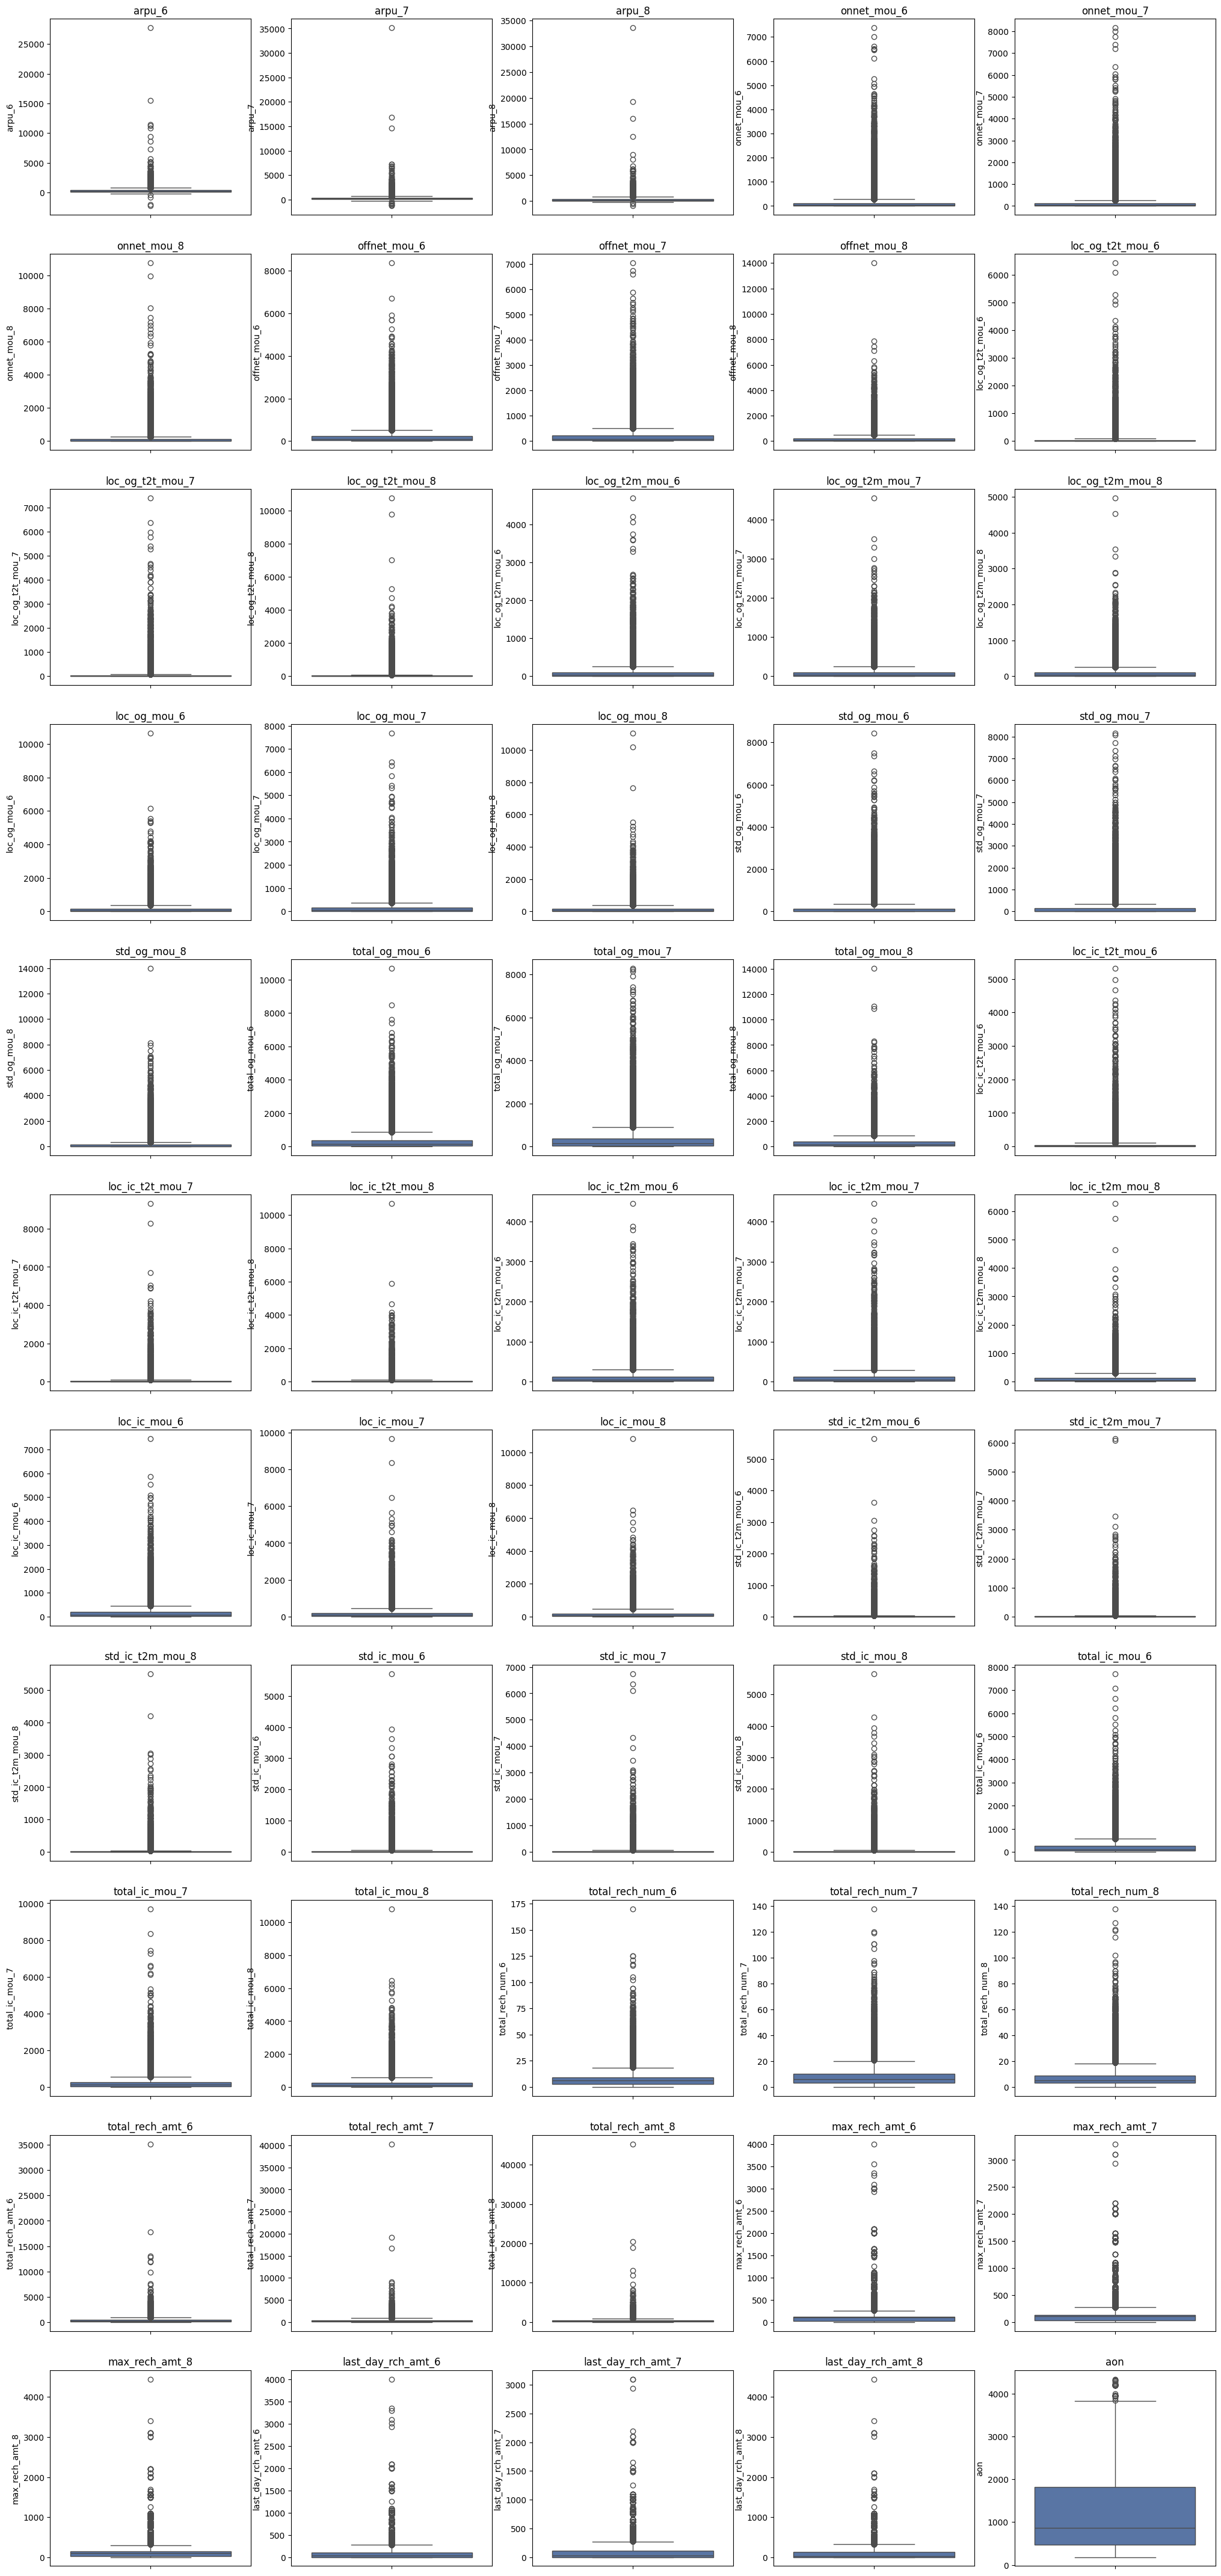

fig_row 11


In [150]:
draw_boxplot(X_clean_data_rm0)

## EDA and Feature Engineering: Handeling Outliers ,  These can be capped with k-sigma method.

In [151]:
def cap_outliers(array, k=3):
    upper_limit = array.mean() + k*array.std()
    lower_limit = array.mean() - k*array.std()
    array[array<lower_limit] = lower_limit
    array[array>upper_limit] = upper_limit
    return array

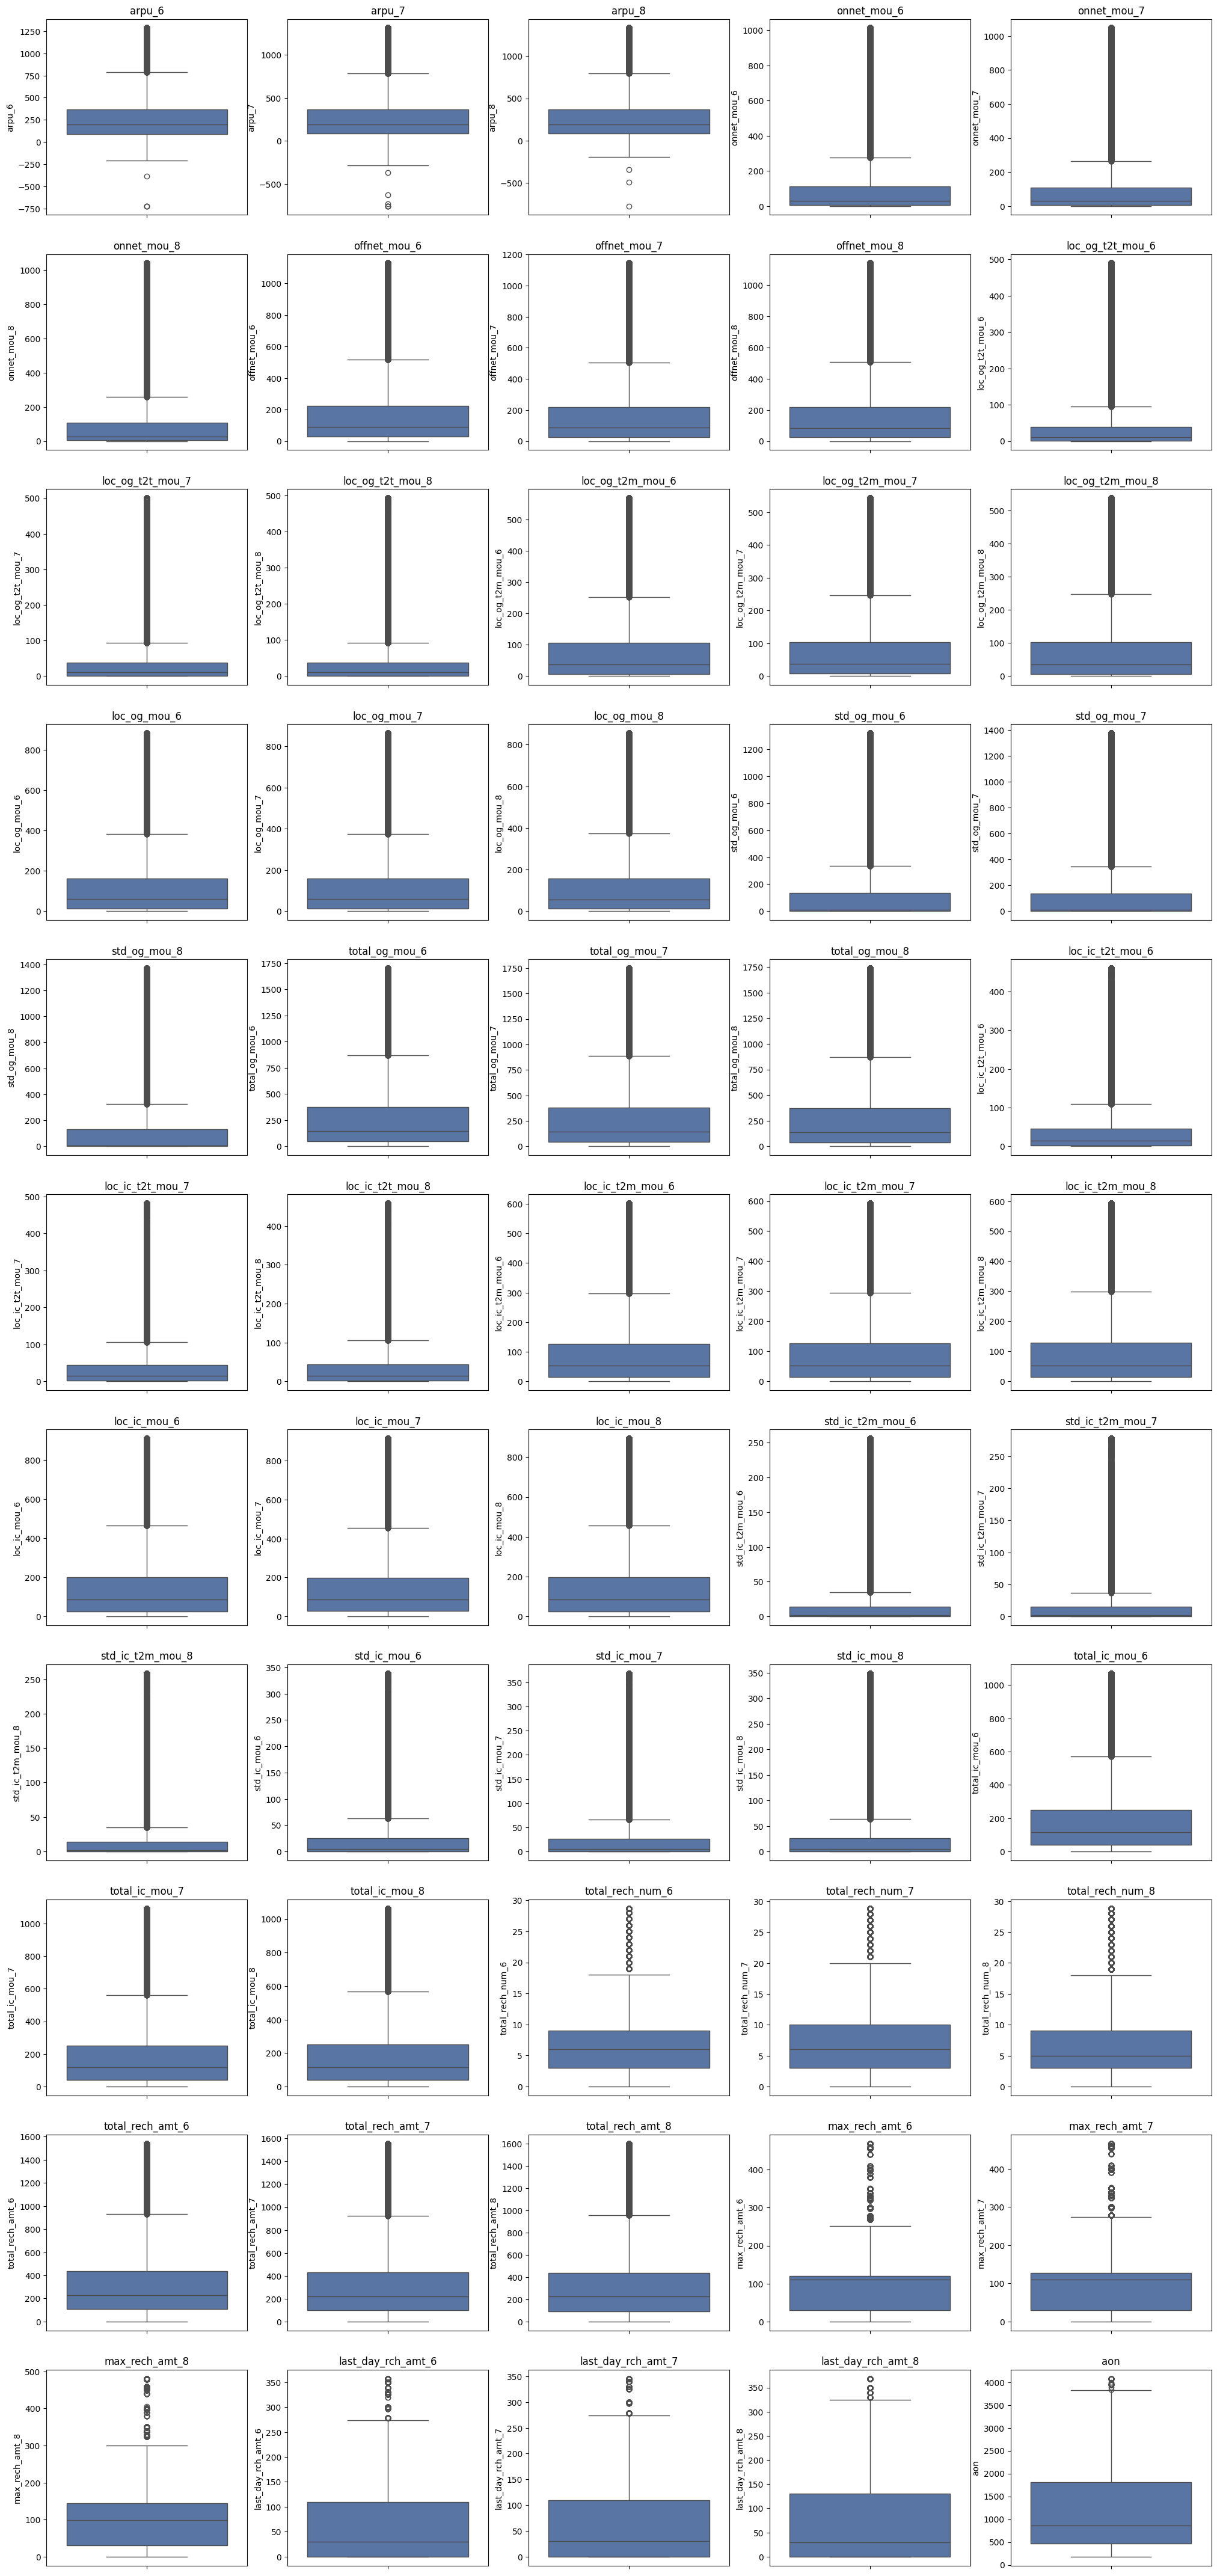

fig_row 11


In [152]:
X_EDA_out = X_clean_data_rm0.apply(cap_outliers,axis=0)
draw_boxplot(X_EDA_out)

## 4. EDA and Feature Engineering: Feature Scaling with help of standard scaler

In [153]:
scaler = StandardScaler()
X_scale = scaler.fit_transform(X_EDA_out)

In [154]:
X_scale.shape

(69999, 55)

In [155]:
y.shape

(69999,)

In [156]:
#  Split train and test
X_train, X_test, y_train, y_test = train_test_split(X_scale, y, test_size=0.3)
# Print the shape
print("Shape of X_train: ",X_train.shape)
print("Shape of X_test: ",X_test.shape)
print("Shape of y_train: ",y_train.shape)
print("Shape of y_test: ",y_test.shape)

Shape of X_train:  (48999, 55)
Shape of X_test:  (21000, 55)
Shape of y_train:  (48999,)
Shape of y_test:  (21000,)


## EDA and Feature Engineering: Correlation analysis between variables and Plotting

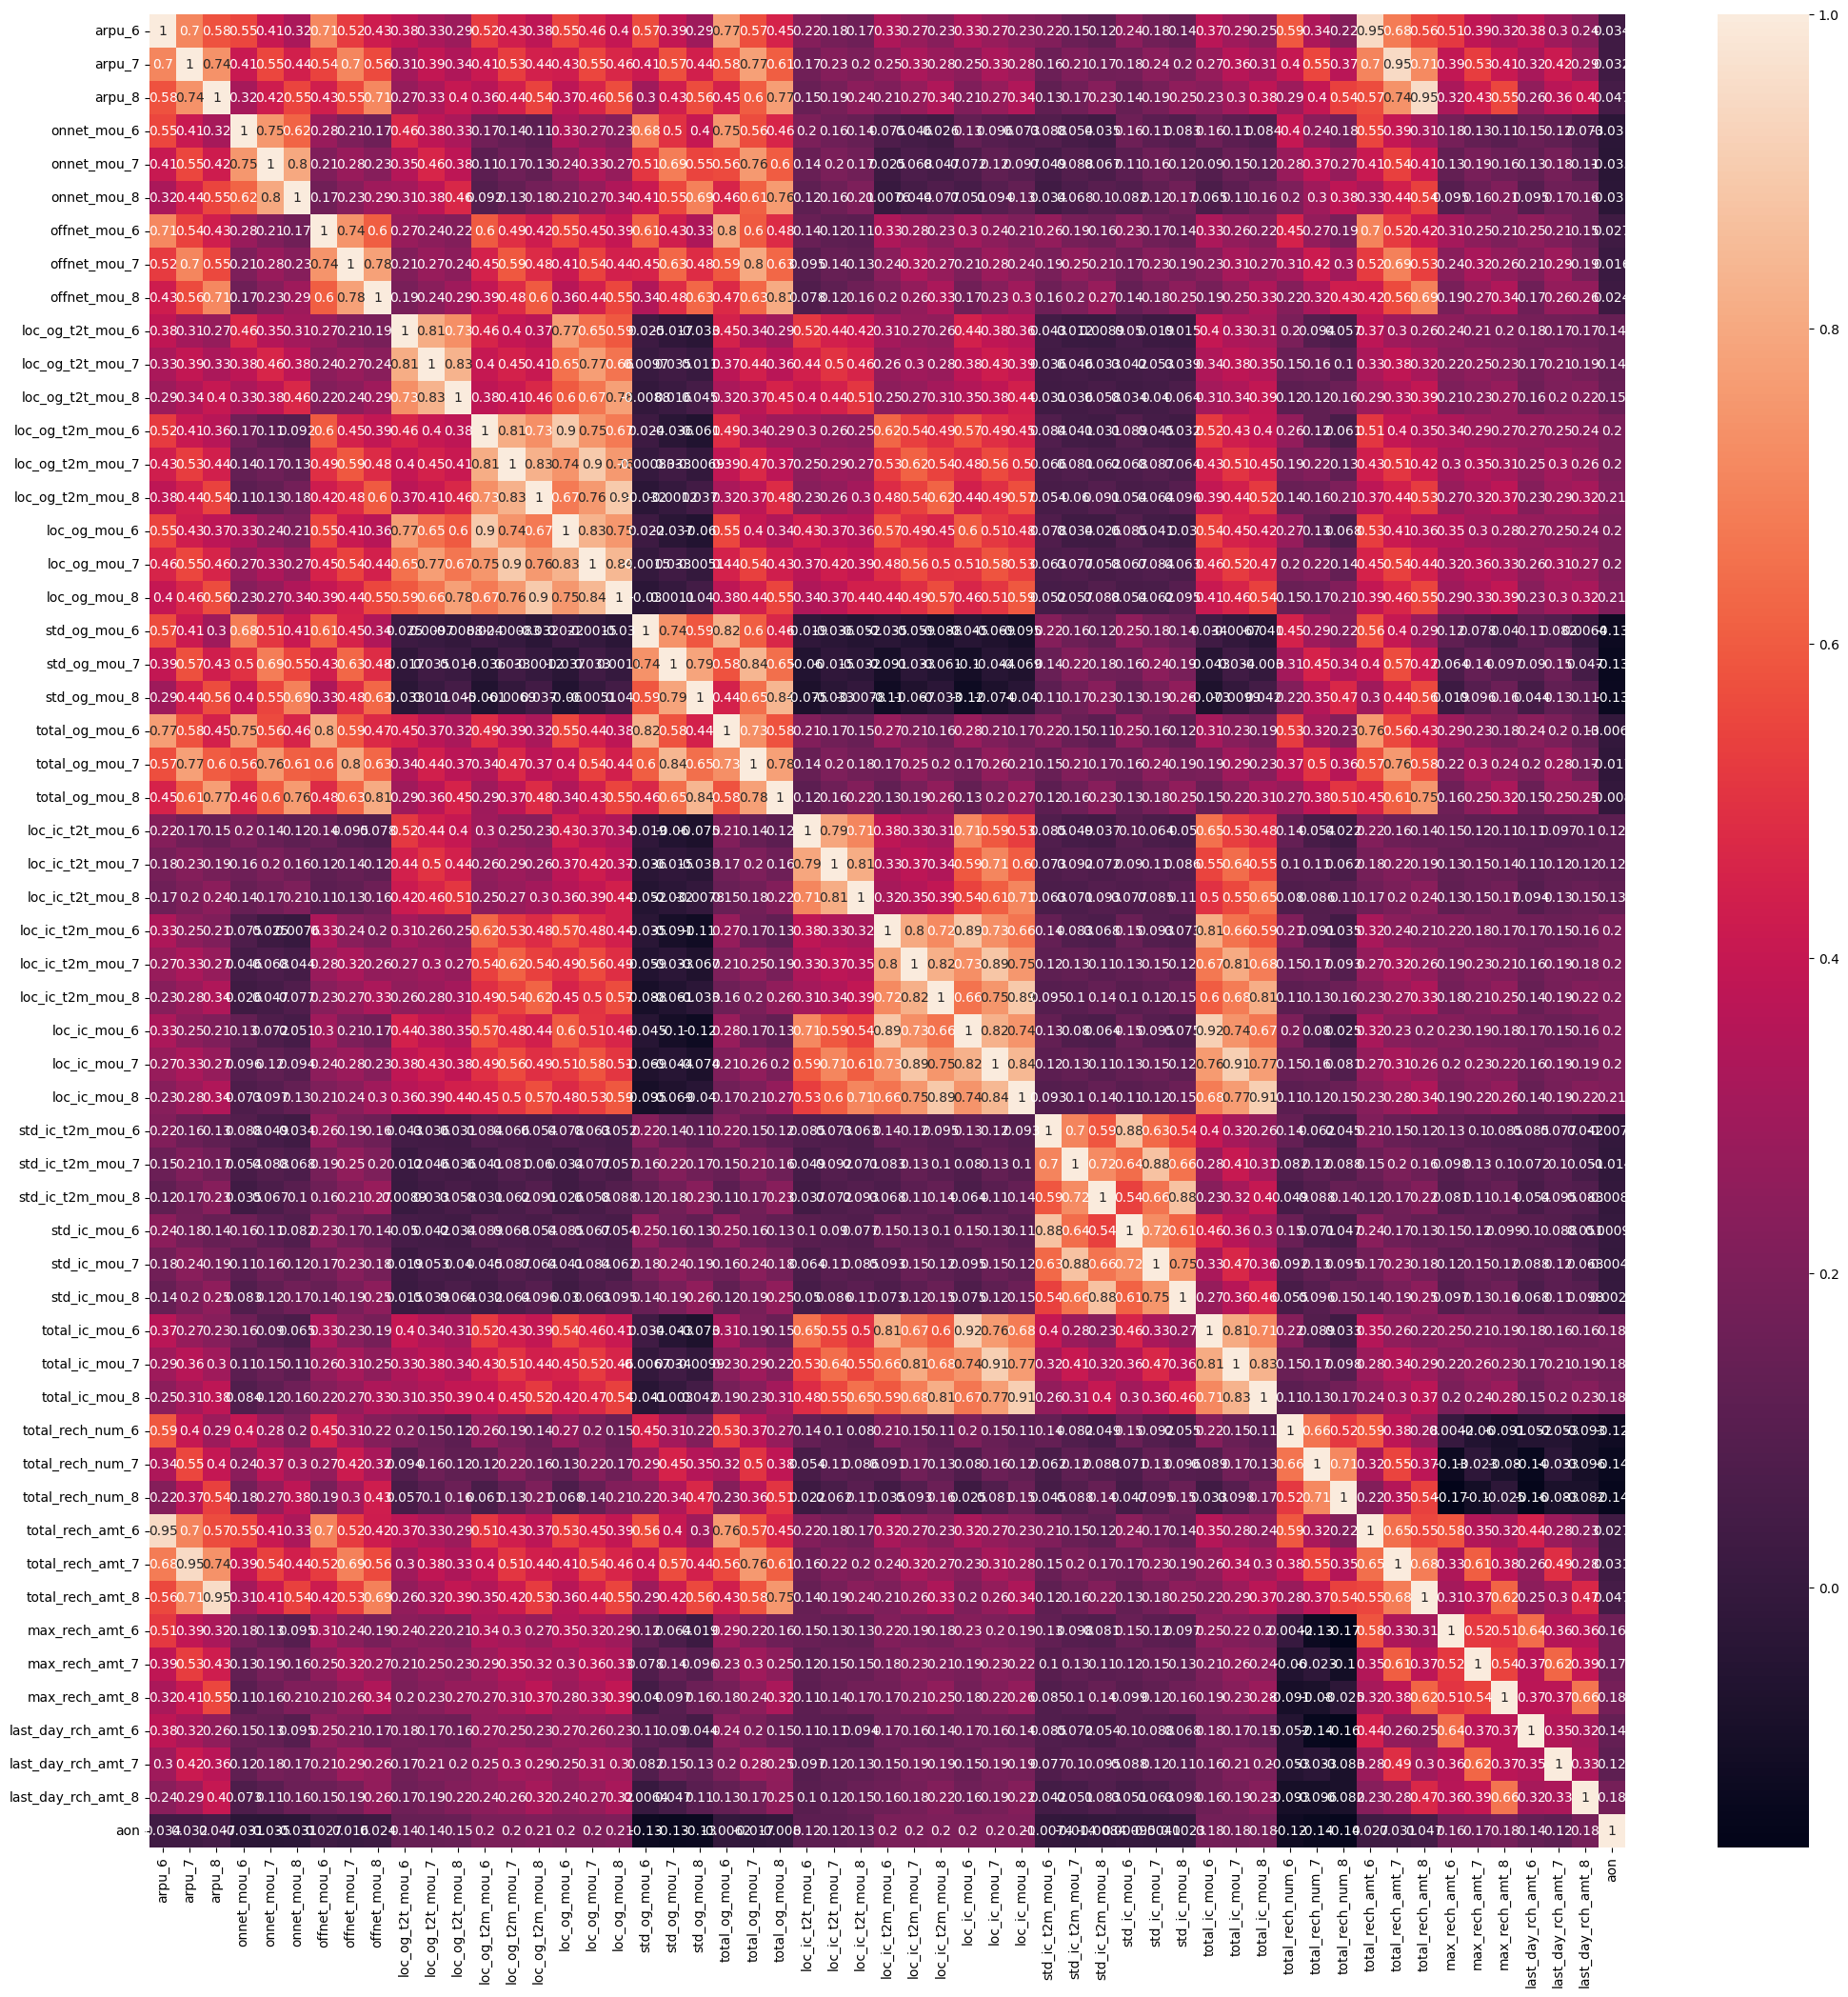

In [157]:
# Plot heat map
# Convert X_train back to a Pandas DataFrame
X_train_df = pd.DataFrame(X_train, columns=X_EDA_out.columns) # Using original columns

plt.figure(figsize=(25,25))
sns.heatmap(X_train_df.corr(),annot=True)
plt.show()

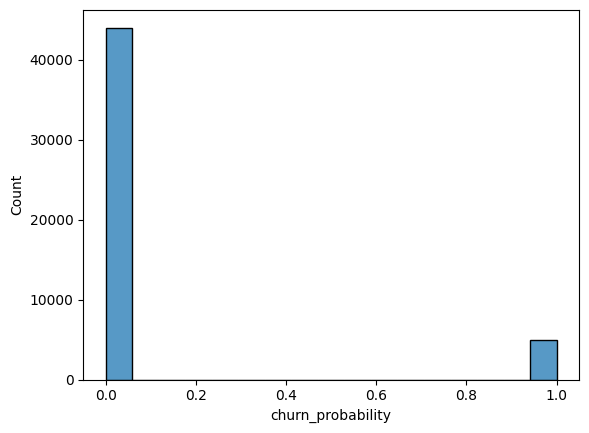

In [158]:
# generate histogram of predictable variable
sns.histplot(y_train)
plt.show()

## 5.EDA and Feature Engineering : Feature engineering and selection

In [159]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

RandomForestClassifier()

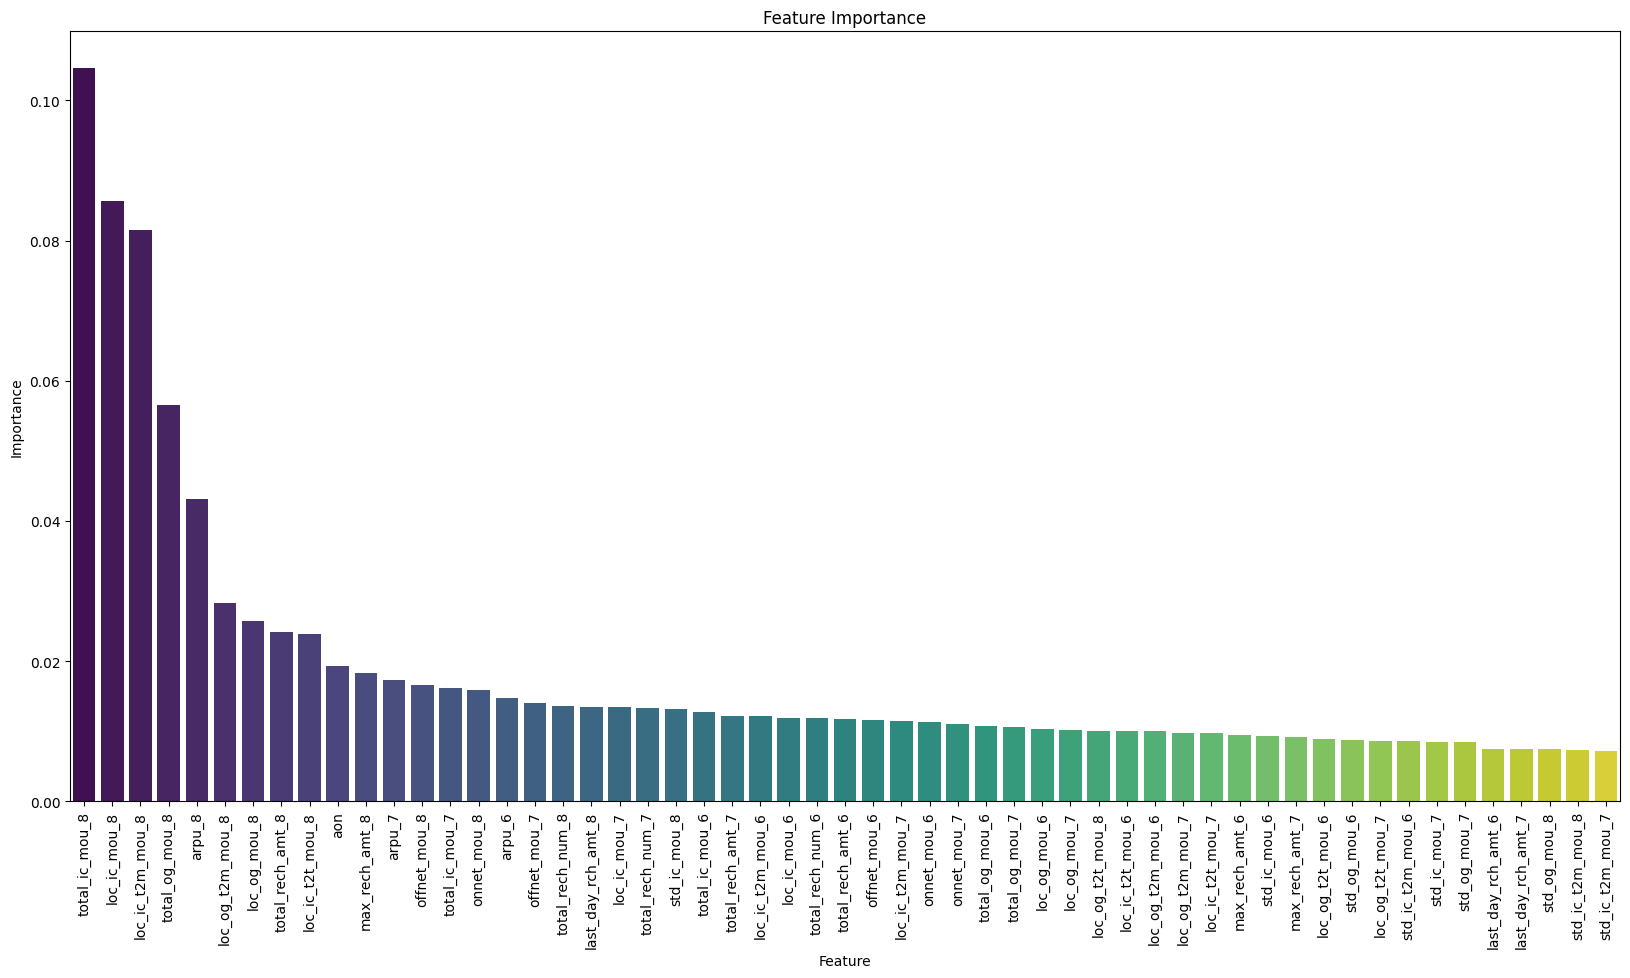

In [160]:
feature_importance = pd.DataFrame({'Feature': X_EDA_out.columns, 'Importance': rf.feature_importances_})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(20, 10))
sns.barplot(x='Feature', y='Importance', data=feature_importance, palette='viridis')
plt.xticks(rotation=90)
plt.title('Feature Importance')
plt.show()

## EDA and Feature Engineering: Applying PCA

In [161]:
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [162]:
# print PCA features
print("PCA features: ",pca.n_components_)
print("Shape of X_train_pca: ",X_train_pca.shape)
print("Shape of X_test_pca: ",X_test_pca.shape)


PCA features:  23
Shape of X_train_pca:  (48999, 23)
Shape of X_test_pca:  (21000, 23)


In [163]:
def draw_scatter_pca_comp(df, n_col=5):
  n_rows = int(np.ceil(df.shape[1]/n_col))
  fig, ax = plt.subplots(nrows=n_rows,ncols=n_col,figsize=(n_col*5, n_rows*5))

  fig_row = 0
  fig_col = 0
  for i in range(df.shape[1]-1):
      sns.scatterplot(x=df[:,i],y=df[:,i+1],ax=ax[fig_row,fig_col], hue=y_train)
      ax[fig_row,fig_col].set_xlabel('component_'+str(i))
      ax[fig_row,fig_col].set_ylabel('component_'+str(i+1))
      fig_col+=1
      if fig_col>4:
        fig_col=0
        fig_row+=1
  plt.show()
  print("fig_row", fig_row)


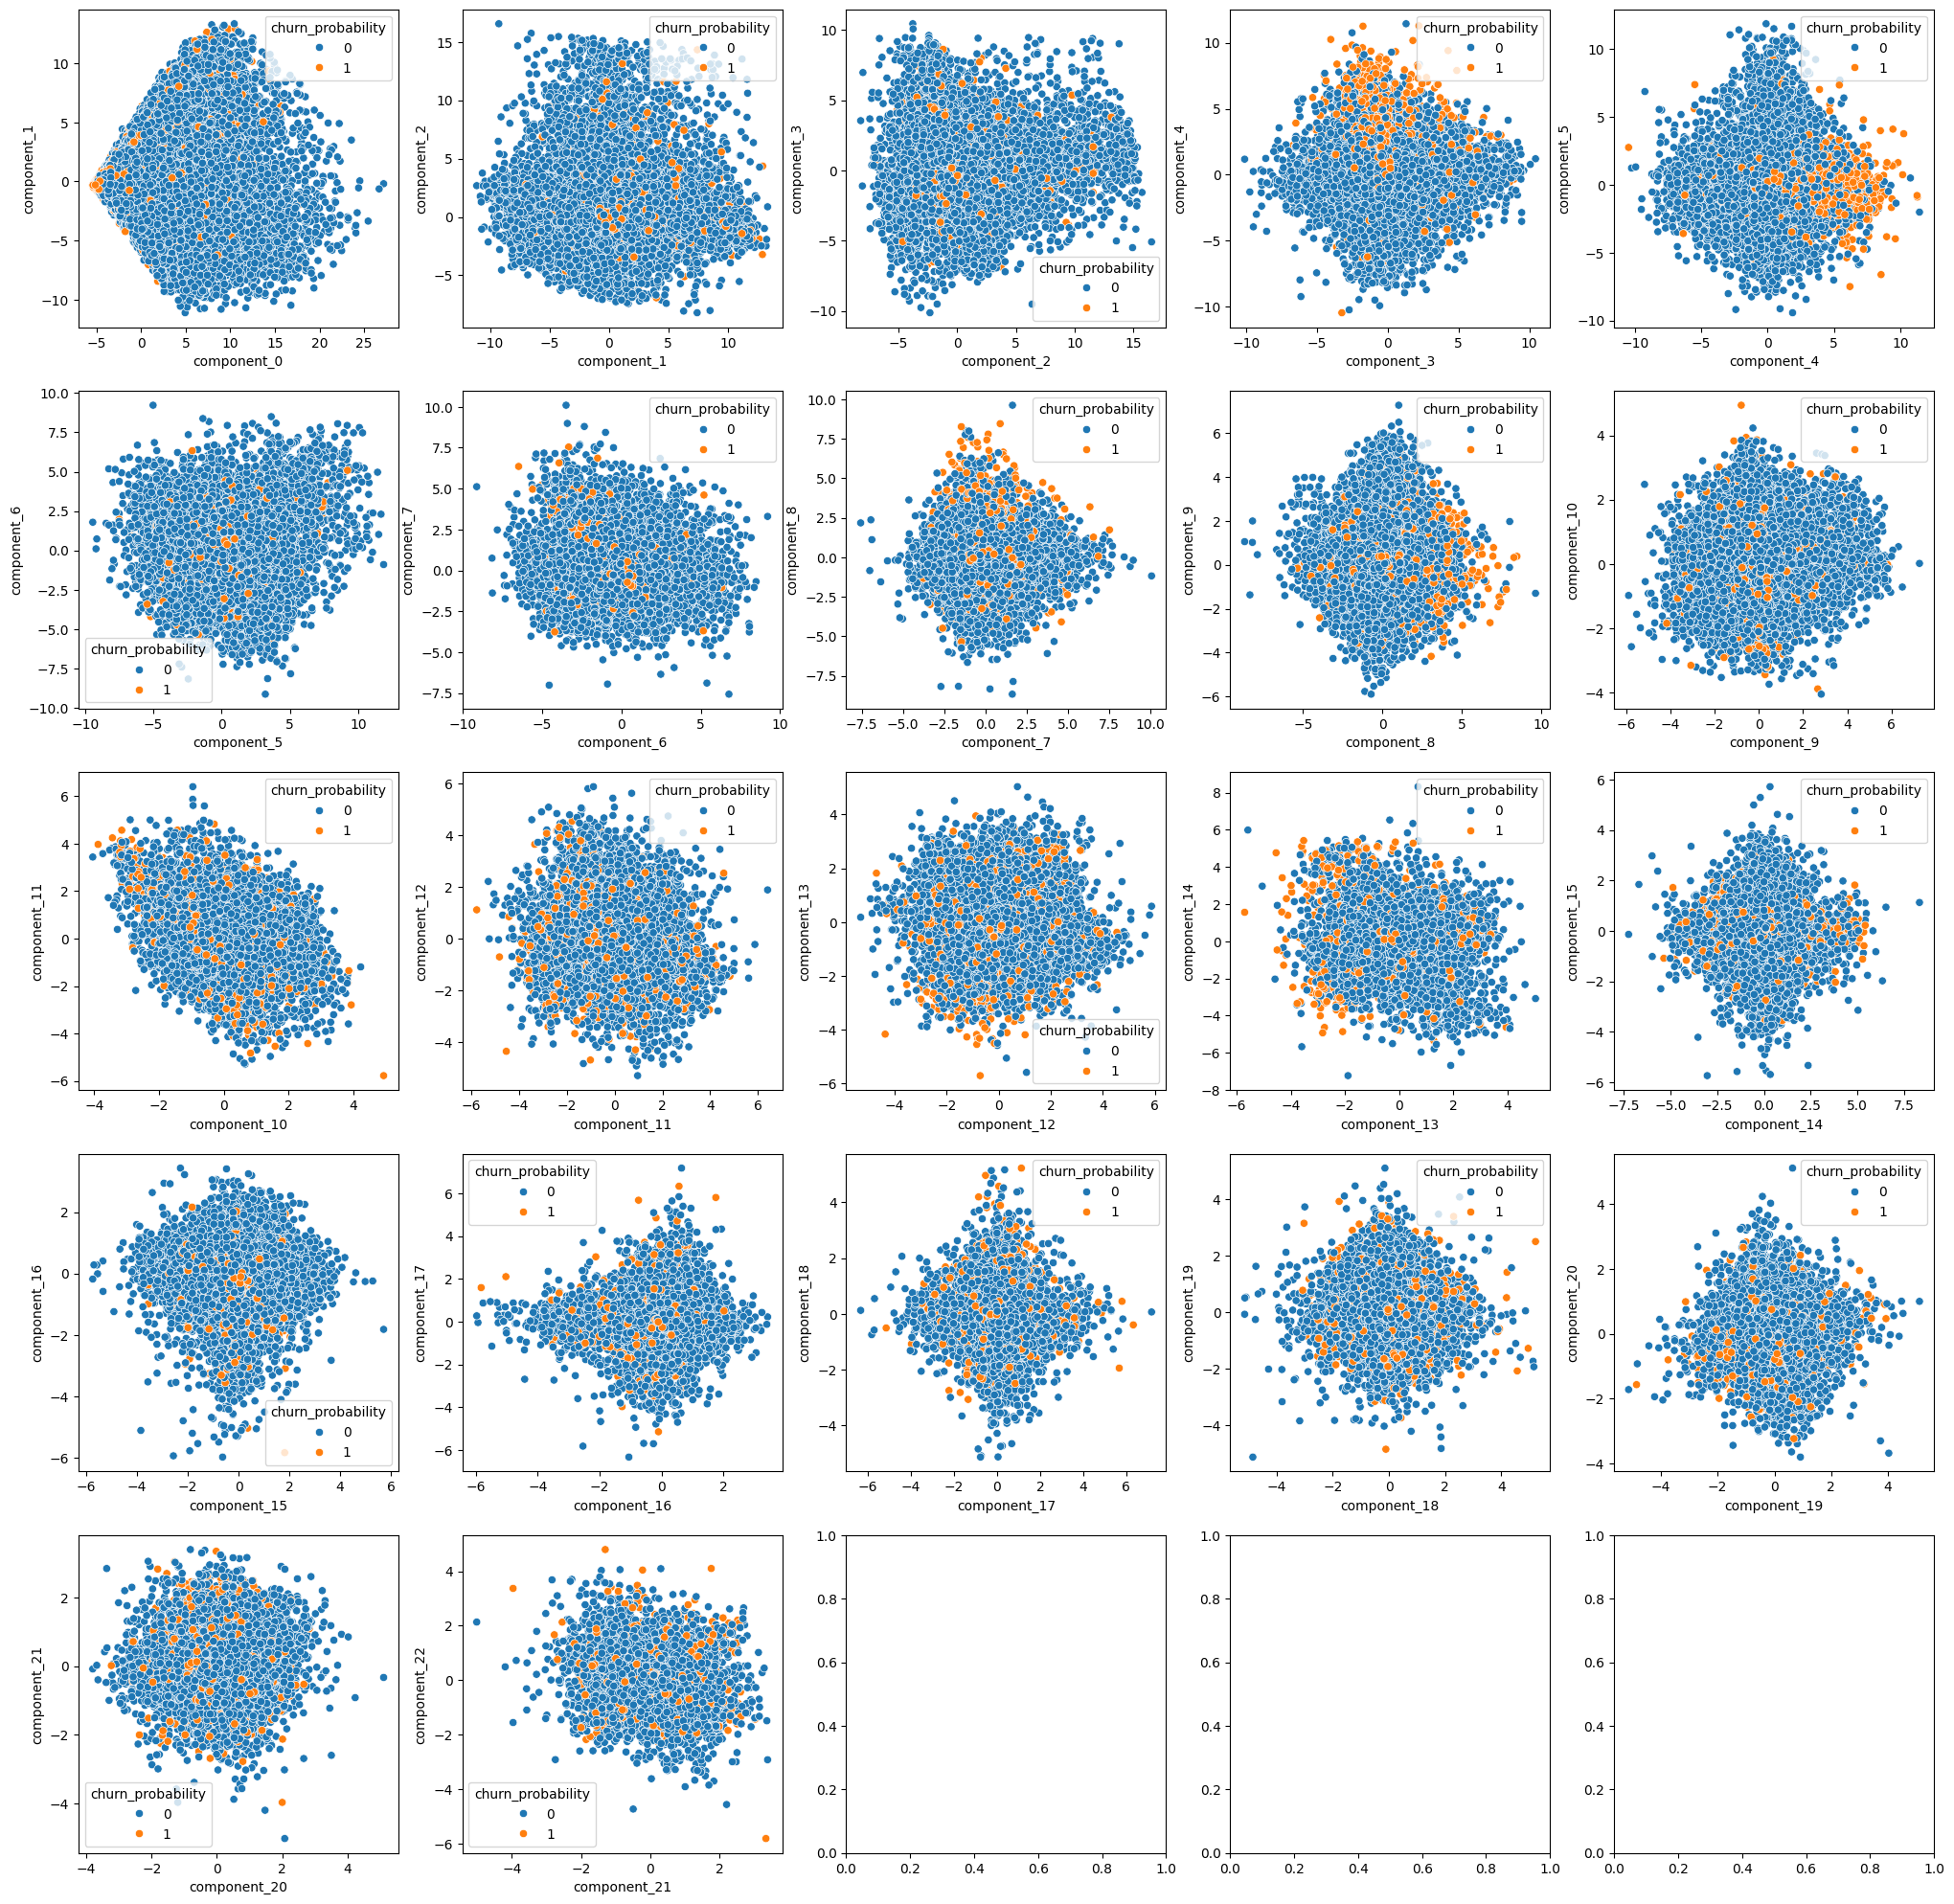

fig_row 4


In [164]:
draw_scatter_pca_comp(X_train_pca)

##EDA and Feature Engineering : Getting feature importance after PCA

In [165]:
rf1= RandomForestClassifier(n_estimators=100)
rf1.fit(X_train_pca, y_train)

RandomForestClassifier()

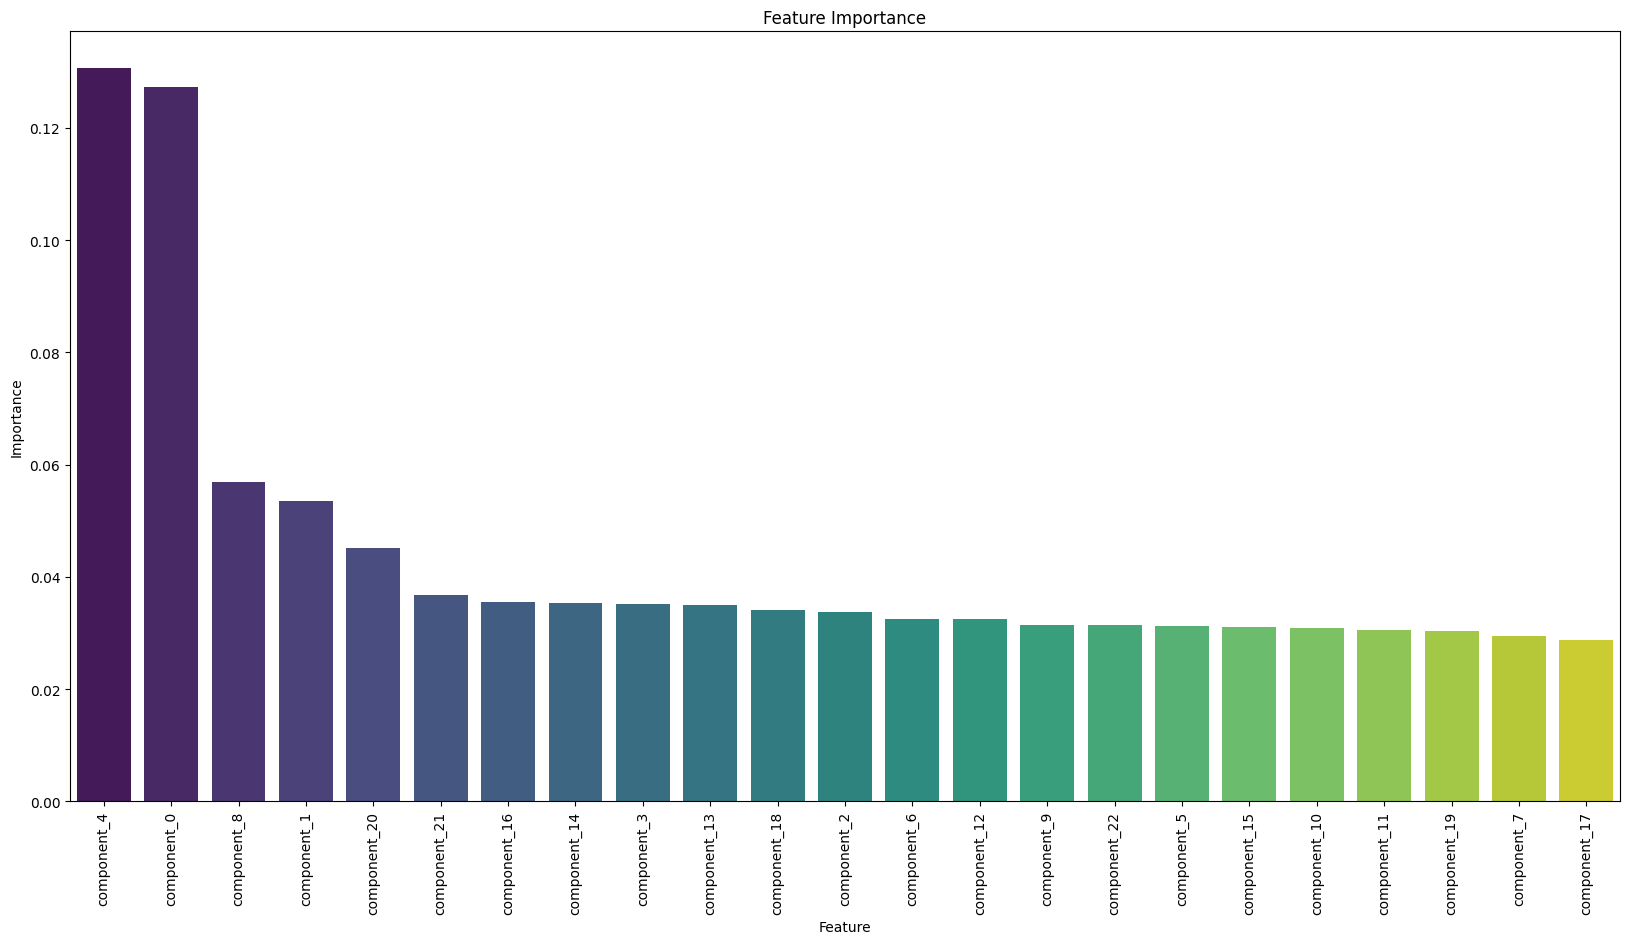

In [166]:
feature_importance_pca = pd.DataFrame({'Feature': ['component_'+str(i) for i in range(X_train_pca.shape[1])], 'Importance': rf1.feature_importances_})
feature_importance_pca = feature_importance_pca.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(20, 10))
sns.barplot(x='Feature', y='Importance', data=feature_importance_pca, palette='viridis')
plt.xticks(rotation=90)
plt.title('Feature Importance')
plt.show()


## 6.Model selection, model building, evaluation & prediction: Logistic Regression Model Building

In [167]:
lgr = LogisticRegression(max_iter=100, tol=0.001, solver='saga')
lgr.fit(X_train_pca, y_train)

LogisticRegression(solver='saga', tol=0.001)

In [168]:
# Accuracy score for train
accuracy_score(y_train, lgr.predict(X_train_pca))

0.9111818608543032

In [169]:
accuracy_score(y_test, lgr.predict(X_test_pca))

0.9111428571428571

In [170]:
# Get confusion matrix
# Confusion Matrix for train
print("Confusion Matrix for Train \n")
print(confusion_matrix(y_train, lgr.predict(X_train_pca)))
print("\n")
# Confusion Matrix for test
print("Confusion Matrix for Test \n")
print(confusion_matrix(y_test, lgr.predict(X_test_pca)))

Confusion Matrix for Train 

[[43535   480]
 [ 3872  1112]]


Confusion Matrix for Test 

[[18637   215]
 [ 1651   497]]


In [171]:
# Print precision score
print("Precision Score for Train \n")
print(precision_score(y_train, lgr.predict(X_train_pca)))
print("\n")
print("Precision Score for Test \n")
print(precision_score(y_test, lgr.predict(X_test_pca)))

Precision Score for Train 

0.6984924623115578


Precision Score for Test 

0.6980337078651685


In [172]:
# Print recall
print("Recall Score for Train \n")
print(recall_score(y_train, lgr.predict(X_train_pca)))
print("\n")
print("Recall Score for Test \n")
print(recall_score(y_test, lgr.predict(X_test_pca)))

Recall Score for Train 

0.2231139646869984


Recall Score for Test 

0.2313780260707635


## Model selection, model building, evaluation & prediction: Preparing file for unseen data for submission


In [173]:
df_telecom_submission.head()

,id,churn_probability
0,69999,0
1,70000,0
2,70001,0
3,70002,0
4,70003,0


In [174]:
df_telecom_test.head()

,id,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,arpu_6,arpu_7,...,sachet_3g_6,sachet_3g_7,sachet_3g_8,fb_user_6,fb_user_7,fb_user_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g
0,69999,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,91.882,65.330,...,0,0,0,NaN,NaN,NaN,1692,0.00,0.00,0.00
1,70000,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,414.168,515.568,...,0,0,0,NaN,NaN,NaN,2533,0.00,0.00,0.00
2,70001,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,329.844,434.884,...,0,0,0,NaN,NaN,NaN,277,525.61,758.41,241.84
3,70002,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,43.550,171.390,...,0,0,0,NaN,NaN,NaN,1244,0.00,0.00,0.00
4,70003,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,306.854,406.289,...,0,0,0,NaN,NaN,NaN,462,0.00,0.00,0.00


In [175]:
unseen_features = df_telecom_test[X_EDA_out.columns]
unseen_features.shape
unseen_features.head()

,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,loc_og_t2t_mou_6,...,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,max_rech_amt_6,max_rech_amt_7,max_rech_amt_8,last_day_rch_amt_6,last_day_rch_amt_7,last_day_rch_amt_8,aon
0,91.882,65.330,64.445,31.78,20.23,23.11,60.16,32.16,34.83,24.88,...,103,90,60,50,30,30,30,30,0,1692
1,414.168,515.568,360.868,75.51,41.21,19.84,474.34,621.84,394.94,75.51,...,500,500,500,250,250,250,250,0,0,2533
2,329.844,434.884,746.239,7.54,7.86,8.40,16.98,45.81,45.04,0.00,...,500,1000,1000,300,500,500,0,0,0,277
3,43.550,171.390,24.400,5.31,2.16,0.00,40.04,205.01,24.01,5.31,...,110,260,0,110,150,0,110,150,0,1244
4,306.854,406.289,413.329,450.93,609.03,700.68,60.94,23.84,74.16,0.45,...,356,490,546,90,130,130,50,130,130,462


In [176]:
unseen_features.info(verbose=1,show_counts=1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 55 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   arpu_6              30000 non-null  float64
 1   arpu_7              30000 non-null  float64
 2   arpu_8              30000 non-null  float64
 3   onnet_mou_6         28831 non-null  float64
 4   onnet_mou_7         28828 non-null  float64
 5   onnet_mou_8         28325 non-null  float64
 6   offnet_mou_6        28831 non-null  float64
 7   offnet_mou_7        28828 non-null  float64
 8   offnet_mou_8        28325 non-null  float64
 9   loc_og_t2t_mou_6    28831 non-null  float64
 10  loc_og_t2t_mou_7    28828 non-null  float64
 11  loc_og_t2t_mou_8    28325 non-null  float64
 12  loc_og_t2m_mou_6    28831 non-null  float64
 13  loc_og_t2m_mou_7    28828 non-null  float64
 14  loc_og_t2m_mou_8    28325 non-null  float64
 15  loc_og_mou_6        28831 non-null  float64
 16  loc_

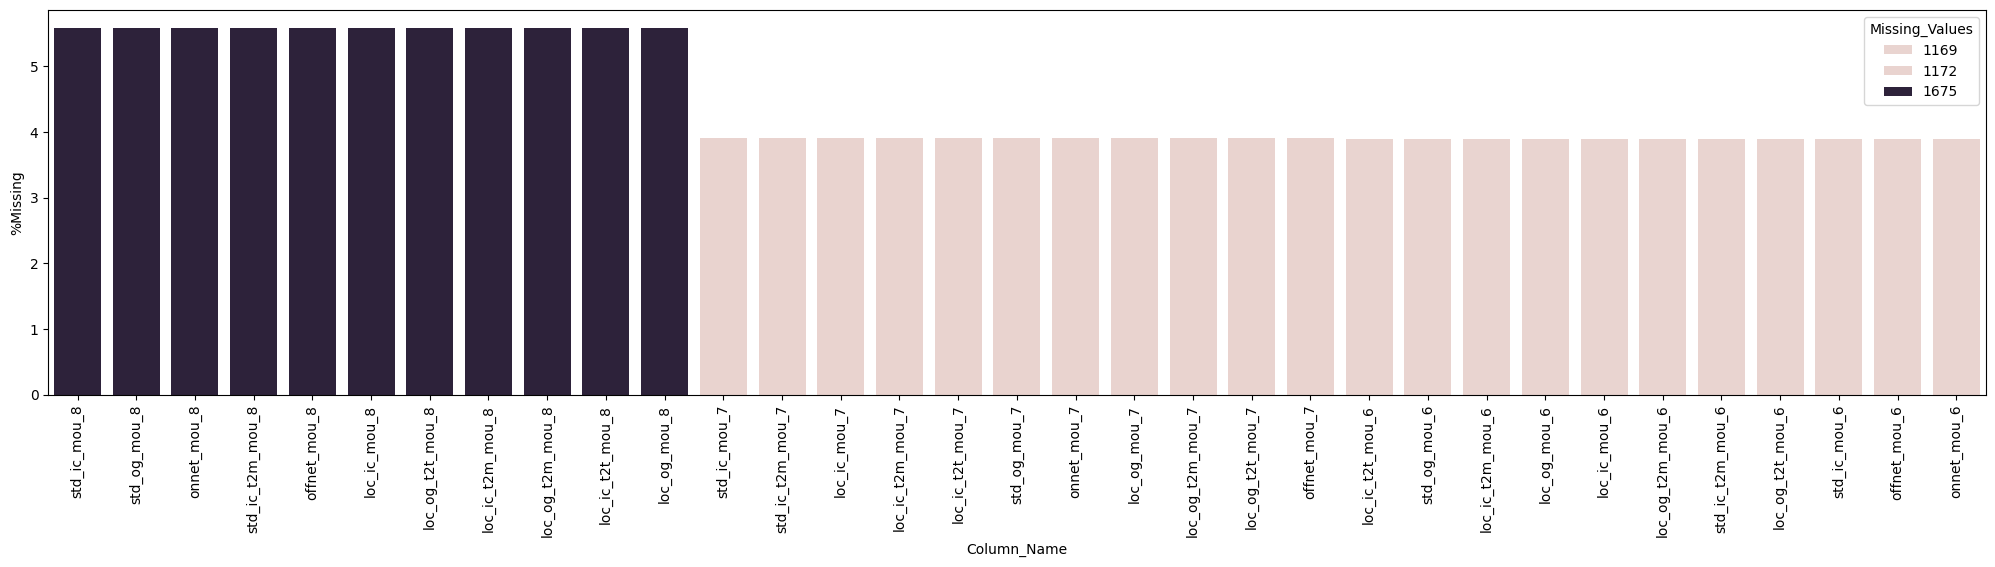

In [177]:
missing_val = unseen_features.isnull().sum()
missing_val = missing_val[missing_val>0].reset_index()
missing_val.columns = ['Column_Name','Missing_Values']
# sort by missing values
missing_val = missing_val.sort_values(by='Missing_Values',ascending=False)
missing_val['%Missing']= round((missing_val['Missing_Values']/unseen_features.shape[0]*100),2)
# Plot missing values
plt.figure(figsize=(25,5))
sns.barplot(x=missing_val['Column_Name'],y=missing_val['%Missing'],hue=missing_val['Missing_Values'])
plt.xticks(rotation=90)
plt.show()

### All missing values is of mou hence changing this to 0




In [178]:
unseen_features.fillna(0,inplace=True)

In [179]:
unseen_features.info(verbose=1,show_counts=1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 55 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   arpu_6              30000 non-null  float64
 1   arpu_7              30000 non-null  float64
 2   arpu_8              30000 non-null  float64
 3   onnet_mou_6         30000 non-null  float64
 4   onnet_mou_7         30000 non-null  float64
 5   onnet_mou_8         30000 non-null  float64
 6   offnet_mou_6        30000 non-null  float64
 7   offnet_mou_7        30000 non-null  float64
 8   offnet_mou_8        30000 non-null  float64
 9   loc_og_t2t_mou_6    30000 non-null  float64
 10  loc_og_t2t_mou_7    30000 non-null  float64
 11  loc_og_t2t_mou_8    30000 non-null  float64
 12  loc_og_t2m_mou_6    30000 non-null  float64
 13  loc_og_t2m_mou_7    30000 non-null  float64
 14  loc_og_t2m_mou_8    30000 non-null  float64
 15  loc_og_mou_6        30000 non-null  float64
 16  loc_

# Scale the test data

In [180]:
unseen_features_scaled = scaler.transform(unseen_features)
df_unseen = pd.DataFrame(unseen_features_scaled, columns=unseen_features.columns)
df_unseen.head()

,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,loc_og_t2t_mou_6,...,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,max_rech_amt_6,max_rech_amt_7,max_rech_amt_8,last_day_rch_amt_6,last_day_rch_amt_7,last_day_rch_amt_8,aon
0,-0.697490,-0.775061,-0.768449,-0.397678,-0.442941,-0.423382,-0.496322,-0.598965,-0.580632,-0.178091,...,-0.680507,-0.699044,-0.787650,-0.555224,-0.761376,-0.765070,-0.418460,-0.362861,-0.765447,0.495120
1,0.526696,0.925057,0.334283,-0.187899,-0.345056,-0.438875,1.238783,1.838131,0.920553,0.478955,...,0.572141,0.586185,0.572791,1.655418,1.642546,1.530482,2.644581,-0.781703,-0.765447,1.378362
2,0.206396,0.620390,1.767912,-0.513961,-0.500654,-0.493075,-0.677214,-0.542551,-0.538070,-0.500968,...,0.572141,2.153538,2.118746,2.208078,4.374275,4.139065,-0.836147,-0.781703,-0.765447,-0.990953
3,-0.881077,-0.374574,-0.917421,-0.524658,-0.527248,-0.532873,-0.580610,0.115409,-0.625738,-0.432058,...,-0.658420,-0.166144,-0.973165,0.107969,0.549854,-1.078100,0.695373,1.312510,-0.765447,0.024617
4,0.119070,0.512415,0.529444,1.613041,2.304170,2.786793,-0.493054,-0.633351,-0.416678,-0.495129,...,0.117780,0.554838,0.715018,-0.113096,0.331316,0.278363,-0.140001,1.033281,0.917162,-0.796661


In [181]:
# Doining component analysis
df_unseen_pca = pca.transform(df_unseen)

In [182]:
df_telecom_test['churn_probability'] = lgr.predict(df_unseen_pca)

In [183]:

output = df_telecom_test[['id','churn_probability']]
output.head()

,id,churn_probability
0,69999,0
1,70000,0
2,70001,0
3,70002,0
4,70003,0


In [207]:
# Get the current date
now = datetime.datetime.now()

# Format the date and time as a string
formatted_date = now.strftime("%Y-%m-%d_%H-%M-%S")

# Create the file name with the date suffix
file_name = f"/content/drive/MyDrive/Data-For-Analysis/Kaggle/Telecom_Churn/output_submission_LR_{formatted_date }.csv"

output.to_csv(file_name,index=False)


## Model selection, model building, evaluation & prediction: Model generation using support vector *machine*


In [185]:
# implementing support vector machine
svm = SVC(kernel='linear', C=1)
svm.fit(X_train_pca, y_train)

SVC(C=1, kernel='linear')

In [186]:
# Print the accuracy score
print("Accuracy score for train: ",accuracy_score(y_train, svm.predict(X_train_pca)))
print("Accuracy score for test: ",accuracy_score(y_test, svm.predict(X_test_pca)))

Accuracy score for train:  0.8982836384416009
Accuracy score for test:  0.8977142857142857


### Ignoring SVC as accuracy score is lesser than Logistic Regression

## Model selection, model building, evaluation & prediction : Model generation using Decision tree



In [187]:
# create decision tree
dt = DecisionTreeClassifier()
dt.fit(X_train_pca, y_train)

DecisionTreeClassifier()

In [188]:
# print accuracy score
print("Accuracy score for train: ",accuracy_score(y_train, dt.predict(X_train_pca)))
print("Accuracy score for test: ",accuracy_score(y_test, dt.predict(X_test_pca)))

Accuracy score for train:  1.0
Accuracy score for test:  0.8818095238095238


Test accuracy score is very less hence using grid search to find optimal hyper parameter

In [189]:
# using grid search
param_grid = {
    'max_depth': [5,6,7],
    'min_samples_split': [350,370,390,410,430,450]
}
grid_search = GridSearchCV(dt, param_grid, cv=5)
grid_search.fit(X_train_pca, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [5, 6, 7],
                         'min_samples_split': [350, 370, 390, 410, 430, 450]})

In [190]:
# Get best parameter
print("Best parameters: ",grid_search.best_params_)

Best parameters:  {'max_depth': 6, 'min_samples_split': 390}


In [191]:
dt_grid = DecisionTreeClassifier(max_depth=7, min_samples_split=410)
dt_grid.fit(X_train_pca, y_train)

DecisionTreeClassifier(max_depth=7, min_samples_split=410)

In [192]:
#print accuracy score
print("Accuracy score for train: ",accuracy_score(y_train, dt_grid.predict(X_train_pca)))
print("Accuracy score for test: ",accuracy_score(y_test, dt_grid.predict(X_test_pca)))

Accuracy score for train:  0.91679422029021
Accuracy score for test:  0.9128571428571428


## Accuracy score is better than Logistic regression. Getting other metrics, confucion matrix, precision score and recall score

LR Confusion matrix
Confusion Matrix for Train

[[43495   489]
 [ 3875  1140]]


Confusion Matrix for Test

[[18675   208]
 [ 1656   461]]


 Precision Score for Train

0.6998158379373849


Precision Score for Test

0.6890881913303438

Recall Score for Train

0.22731804586241275


Recall Score for Test

0.21776098252243742

In [193]:
# confusion matrix
print("Confusion Matrix for Train \n")
print(confusion_matrix(y_train, dt_grid.predict(X_train_pca)))
print("\n")
print("Confusion Matrix for Test \n")
print(confusion_matrix(y_test, dt_grid.predict(X_test_pca)))

Confusion Matrix for Train 

[[43163   852]
 [ 3225  1759]]


Confusion Matrix for Test 

[[18420   432]
 [ 1398   750]]


In [194]:
# Print precision score
print("Precision Score for Train \n")
print(precision_score(y_train, dt_grid.predict(X_train_pca)))
print("\n")
print("Precision Score for Test \n")
print(precision_score(y_test, dt_grid.predict(X_test_pca)))

Precision Score for Train 

0.6736882420528533


Precision Score for Test 

0.6345177664974619


In [195]:
# print Recall score
print("Recall Score for Train \n")
print(recall_score(y_train, dt_grid.predict(X_train_pca)))
print("\n")
print("Recall Score for Test \n")
print(recall_score(y_test, dt_grid.predict(X_test_pca)))

Recall Score for Train 

0.35292937399678975


Recall Score for Test 

0.34916201117318435


## In this case recall is has better score hence preparing file for unseendata

In [196]:
# Predicting unseen probablity
df_telecom_submission['churn_probability'] = dt_grid.predict(df_unseen_pca)


In [197]:
output_dt = df_telecom_test[['id','churn_probability']]
output_dt.head()

,id,churn_probability
0,69999,0
1,70000,0
2,70001,0
3,70002,0
4,70003,0


In [208]:
# Format the date and time as a string
formatted_date = now.strftime("%Y-%m-%d_%H-%M-%S")

# Create the file name with the date suffix
file_name = f"/content/drive/MyDrive/Data-For-Analysis/Kaggle/Telecom_Churn/output_submission_DT_{formatted_date}.csv"

output.to_csv(file_name,index=False)


## Model selection, model building, evaluation & prediction:Bulding Model using Random Forrest

In [199]:
# building random forrest
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train_pca, y_train)

RandomForestClassifier()

In [200]:
# Print accuray score
print("Accuracy score for train: ",accuracy_score(y_train, rf.predict(X_train_pca)))
print("Accuracy score for test: ",accuracy_score(y_test, rf.predict(X_test_pca)))

Accuracy score for train:  0.9999795914202331
Accuracy score for test:  0.9190952380952381


## This has better accuracy score in all
Checkimg best hyper parameter using grid search

In [201]:
# implement grid search
param_grid = {
    'n_estimators': [100,150,200,250,300]
}
grid_search_rf = GridSearchCV(rf, param_grid, cv=5)
grid_search_rf.fit(X_train_pca, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'n_estimators': [100, 150, 200, 250, 300]})

In [202]:
# print best parameter
print("Best parameters: ",grid_search_rf.best_params_)


Best parameters:  {'n_estimators': 200}


In [203]:
# best rf
rf_grid = RandomForestClassifier(n_estimators=200)
rf_grid.fit(X_train_pca, y_train)

RandomForestClassifier(n_estimators=200)

In [204]:
# print accuracy score with best parameters
print("Accuracy score for train: ",accuracy_score(y_train, rf_grid.predict(X_train_pca)))
print("Accuracy score for test: ",accuracy_score(y_test, rf_grid.predict(X_test_pca)))

Accuracy score for train:  1.0
Accuracy score for test:  0.919


# Get the precision score and recall score

In [205]:
# print Precision score
print("Precision Score for Train \n")
print(precision_score(y_train, rf_grid.predict(X_train_pca)))
print("\n")
print("Precision Score for Test \n")
print(precision_score(y_test, rf_grid.predict(X_test_pca)))

Precision Score for Train 

1.0


Precision Score for Test 

0.7126546146527117


In [206]:
# print recall score
print("Recall Score for Train \n")
print(recall_score(y_train, rf_grid.predict(X_train_pca)))
print("\n")
print("Recall Score for Test \n")
print(recall_score(y_test, rf_grid.predict(X_test_pca)))
#

Recall Score for Train 

1.0


Recall Score for Test 

0.34869646182495345


# There is lot of variation in train and test score, seems model is unstable.